This file looks at how Validation Curves works. A validation curve sees how changing a single hyperparaneters can make the model overfit or underfit.

Instead of guessing for which n_estimators would be best, try different values & plot.

Below is just imports and arrays

In [ ]:
import numpy as np
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

X=np.array([
    [1200, 2],
    [1500, 3],
    [1600, 3],
    [1800, 3],
    [2000, 4],
    [2200, 4],
    [2500, 4],
    [2700, 5],
    [3000, 5],
    [3200, 5],
    [3500, 6],
    [3800, 6],
    [4200, 7],
    [4500, 7],
    [5000, 8]
])

Y=np.array([
    180000,
    220000,
    240000,
    280000,
    320000,
    350000,
    390000,
    430000,
    480000,
    520000,
    600000,
    650000,
    720000,
    780000,
    900000
])

model = RandomForestRegressor(
    random_state=11
)


This code does multiple things
 - Firstly there is a range for parameters (in our case max_depth)
 - Next we use valdiation_curve(in which train/test/split is not requires)
 - We score R2 and use 5-fold CV.
 - Finally we calculate the means for comparing and later plottting

In [ ]:
range = [1,3,5,7,9,11]
train, valid = validation_curve(
    estimator=model,
    X=X, y=Y, param_name="max_depth",
    param_range=range,
    cv=5, scoring="r2"   
)
train_mean = train.mean(axis=1)
valid_mean = valid.mean(axis=1)
print(train)
print(valid)

Here is all matplotlab!
- We plot the train and valid means
- Set the X & Y axis and show the graph

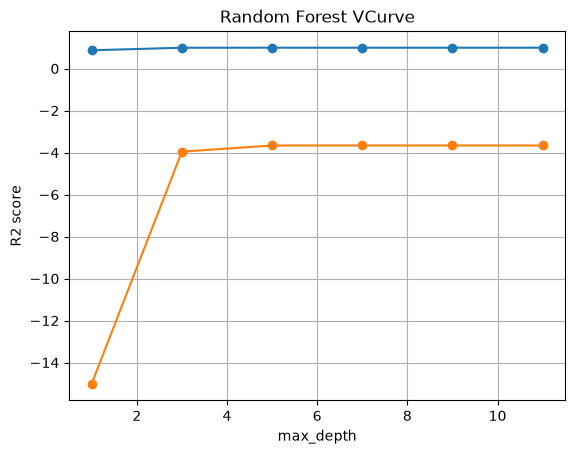

In [13]:

plt.plot(
    range, 
    train_mean, 
    marker="o", 
)
plt.plot(
    range, 
    valid_mean, 
    marker="o", 
)

plt.xlabel("max_depth")
plt.ylabel("R2 score")
plt.title("Random Forest VCurve")

plt.grid()
plt.show()